In [ ]:
pip install pyspark


In [ ]:
from pyspark.sql import SparkSession

# Initialize Spark Session
spark = SparkSession.builder \
    .appName("Big Data Analysis") \
    .getOrCreate()

# Load Dataset
data_path = "/content/yellow_tripdata_2019-01.csv"
df = spark.read.csv(data_path, header=True, inferSchema=True)

# Display Schema
df.printSchema()
df.show(5)


root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: integer (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: integer (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: integer (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: integer (nullable = true)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+--

In [ ]:
# Drop Missing Values
df_cleaned = df.dropna()

# Cast Column Data Types (e.g., Convert Pickup Time to Timestamp)
from pyspark.sql.functions import col
df_cleaned = df_cleaned.withColumn("tpep_pickup_datetime", col("tpep_pickup_datetime").cast("timestamp"))
df_cleaned = df_cleaned.withColumn("tpep_dropoff_datetime", col("tpep_dropoff_datetime").cast("timestamp"))

df_cleaned.show(5)


+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+
|       1| 2019-01-01 07:01:20|  2019-01-31 14:29:21|              1|          1.2|         1|                 N|          48|         163|           2|        6.5|  0.0|    0.5|       0.0|         0.0|                  0.3

In [ ]:
from pyspark.sql.functions import hour, count

df_cleaned.groupBy(hour("tpep_pickup_datetime").alias("hour")) \
    .agg(count("*").alias("total_trips")) \
    .orderBy("hour") \
    .show()


+----+-----------+
|hour|total_trips|
+----+-----------+
|   7|          1|
|  21|          2|
|  22|          2|
+----+-----------+



In [ ]:
df_cleaned.groupBy().avg("trip_distance").show()


+------------------+
|avg(trip_distance)|
+------------------+
|              1.52|
+------------------+



In [ ]:
from pyspark.sql.functions import hour, count

# Group by Hour and Count Trips
peak_hours = df_cleaned.groupBy(hour("tpep_pickup_datetime").alias("hour")) \
    .agg(count("*").alias("total_trips")) \
    .orderBy("total_trips", ascending=False)

# Show Top Peak Hours
peak_hours.show(5)


+----+-----------+
|hour|total_trips|
+----+-----------+
|  22|          2|
|  21|          2|
|   7|          1|
+----+-----------+



In [ ]:
from pyspark.sql.functions import sum

# Sum Up Total Fare Amount
total_revenue = df_cleaned.agg(sum("fare_amount").alias("total_revenue"))
total_revenue.show()


+-------------+
|total_revenue|
+-------------+
|         40.0|
+-------------+



In [ ]:
from pyspark.sql import functions as F

# Calculate IQR
q1, q3 = df_cleaned.approxQuantile("trip_distance", [0.25, 0.75], 0)  # Call approxQuantile on the DataFrame
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Filter Outliers
outliers = df_cleaned.filter((F.col("trip_distance") < lower_bound) | (F.col("trip_distance") > upper_bound)) # Use F.col
outliers.show(5)

# Count Total Outliers
outliers_count = outliers.count()
print(f"Total Outliers: {outliers_count}")

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------

In [ ]:
output_path = "path/to/output"
df_cleaned.write.csv(output_path, header=True)


In [ ]:
from pyspark.sql.functions import unix_timestamp, col

# Calculate Trip Duration in Minutes
df_cleaned = df_cleaned.withColumn(
    "trip_duration_minutes",
    (unix_timestamp("tpep_dropoff_datetime") - unix_timestamp("tpep_pickup_datetime")) / 60
)

# Average Trip Duration
avg_trip_duration = df_cleaned.agg({"trip_duration_minutes": "avg"})
avg_trip_duration.show()

# Longest and Shortest Trips
df_cleaned.orderBy("trip_duration_minutes", ascending=False).select("trip_duration_minutes").show(5)
df_cleaned.orderBy("trip_duration_minutes").select("trip_duration_minutes").show(5)


+--------------------------+
|avg(trip_duration_minutes)|
+--------------------------+
|        15505.626666666667|
+--------------------------+

+---------------------+
|trip_duration_minutes|
+---------------------+
|    43648.01666666667|
|   33856.683333333334|
|   11.583333333333334|
|    9.833333333333334|
|   2.0166666666666666|
+---------------------+

+---------------------+
|trip_duration_minutes|
+---------------------+
|   2.0166666666666666|
|    9.833333333333334|
|   11.583333333333334|
|   33856.683333333334|
|    43648.01666666667|
+---------------------+



In [ ]:
from pyspark.sql.functions import count

# Most Popular Pickup Locations
popular_pickup = df_cleaned.groupBy("PULocationID").agg(count("*").alias("pickup_count")).orderBy("pickup_count", ascending=False)
popular_pickup.show(5)

# Most Popular Dropoff Locations
popular_dropoff = df_cleaned.groupBy("DOLocationID").agg(count("*").alias("dropoff_count")).orderBy("dropoff_count", ascending=False)
popular_dropoff.show(5)


+------------+------------+
|PULocationID|pickup_count|
+------------+------------+
|         263|           2|
|          48|           1|
|         238|           1|
|          50|           1|
+------------+------------+

+------------+-------------+
|DOLocationID|dropoff_count|
+------------+-------------+
|         163|            1|
|         246|            1|
|         141|            1|
|         151|            1|
|         170|            1|
+------------+-------------+



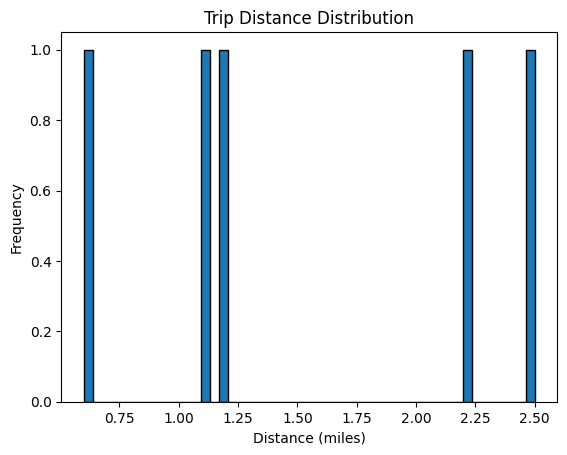

In [ ]:
import matplotlib.pyplot as plt

# Collect Data for Plotting
trip_distances = df_cleaned.select("trip_distance").rdd.flatMap(lambda x: x).collect()

# Plot Histogram
plt.hist(trip_distances, bins=50, edgecolor='k')
plt.title("Trip Distance Distribution")
plt.xlabel("Distance (miles)")
plt.ylabel("Frequency")
plt.show()


In [ ]:
from pyspark.sql.functions import hour, sum

# Revenue by Hour
revenue_by_hour = df_cleaned.groupBy(hour("tpep_pickup_datetime").alias("hour")) \
    .agg(sum("fare_amount").alias("total_revenue")) \
    .orderBy("hour")

revenue_by_hour.show()


+----+-------------+
|hour|total_revenue|
+----+-------------+
|   7|          6.5|
|  21|         14.0|
|  22|         19.5|
+----+-------------+



In [ ]:
from pyspark.sql.functions import to_date

# Group by Date
trips_by_date = df_cleaned.groupBy(to_date("tpep_pickup_datetime").alias("date")) \
    .agg(count("*").alias("total_trips")) \
    .orderBy("date")

trips_by_date.show()


+----------+-----------+
|      date|total_trips|
+----------+-----------+
|2019-01-01|          1|
|2019-01-03|          4|
+----------+-----------+



In [ ]:
df_cleaned.select("trip_distance", "fare_amount").describe().show()

# Optionally, use visualization libraries to plot scatter plots (e.g., matplotlib in PySpark).


+-------+------------------+-----------------+
|summary|     trip_distance|      fare_amount|
+-------+------------------+-----------------+
|  count|                 5|                5|
|   mean|              1.52|              8.0|
| stddev|0.7981227975693966|2.806243040080456|
|    min|               0.6|              4.0|
|    max|               2.5|             11.0|
+-------+------------------+-----------------+

